
**Convolutional Neural Networks (CNNs) for Image Classification**

**Introduction**

Convolutional Neural Networks (CNNs) are a type of deep learning model designed for image processing and computer vision tasks. CNNs automatically learn important features from images using convolutional and pooling layers, making them highly effective for image classification.

In this project, a CNN model is developed using TensorFlow and Keras to classify handwritten digit images from the MNIST dataset. The model is trained, evaluated, and its performance is analyzed using accuracy, loss curves, a confusion matrix, and a classification report.




**Objectives**

The objectives of this project are:

Load and preprocess the MNIST image dataset.
Build a Convolutional Neural Network (CNN).
Train the CNN model using TensorFlow and Keras.
Evaluate the model on test data.
Generate a confusion matrix and classification report.
Understand the working of convolutional layers, pooling layers, activation functions, and dropout.

**Import Libraries**

The required libraries are imported for data loading, preprocessing, visualization, building the CNN model, training, and evaluation.

In [3]:
# Data manipulation
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Model evaluation
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
import tensorflow as tf

print(tf.__version__)

2.20.0


**Load the MNIST Dataset**

The MNIST dataset is loaded directly using TensorFlow.

It consists of:

60,000 training images
10,000 testing images
28 × 28 grayscale images
10 output classes (digits 0–9)
The dataset is widely used for image classification tasks and serves as a standard benchmark for deep learning models.

In [5]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
# Display dataset shapes

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [7]:
# Display unique class labels

print("Classes:", np.unique(y_train))

Classes: [0 1 2 3 4 5 6 7 8 9]


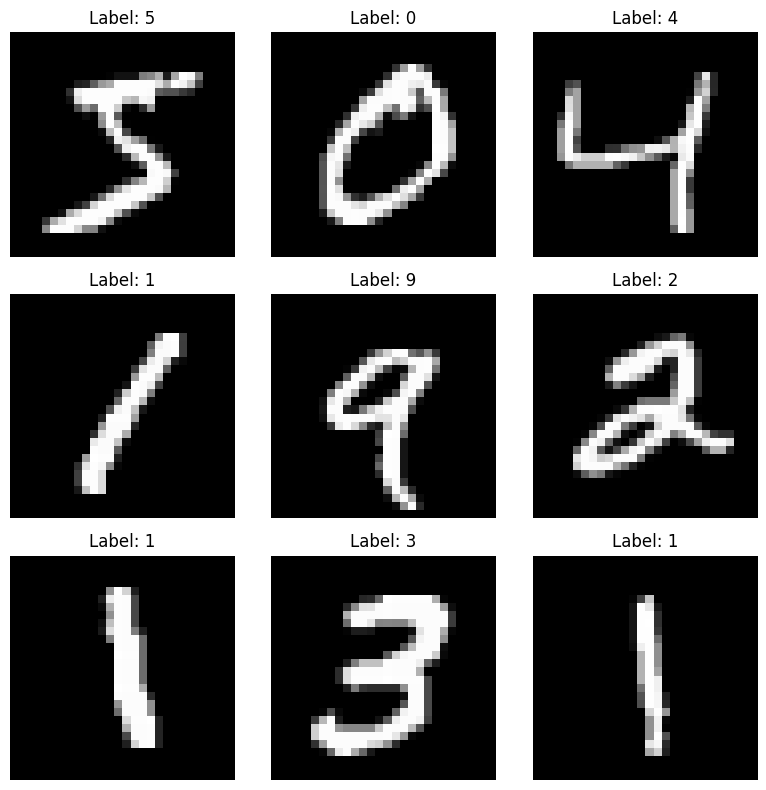

In [8]:
# Display the first 9 images

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Check pixel value range

print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Observation

- The dataset contains **60,000 training images** and **10,000 testing images**.
- Each image has a size of **28 × 28 pixels**.
- There are **10 classes**, representing digits from **0 to 9**.
- Pixel values range from **0 to 255**, so normalization will be required before training the CNN.

#  Exploratory Data Analysis (EDA)

Before training the CNN model, it is important to explore the dataset.

In this section, we will:

- Display the distribution of digit classes.
- Visualize sample images.
- Understand the structure of the dataset.

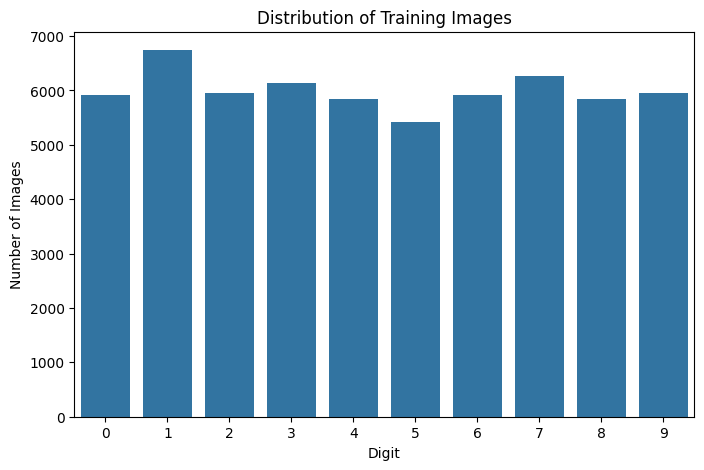

In [10]:
# Count images in each digit class

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
sns.barplot(x=unique, y=counts)

plt.title("Distribution of Training Images")
plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.show()

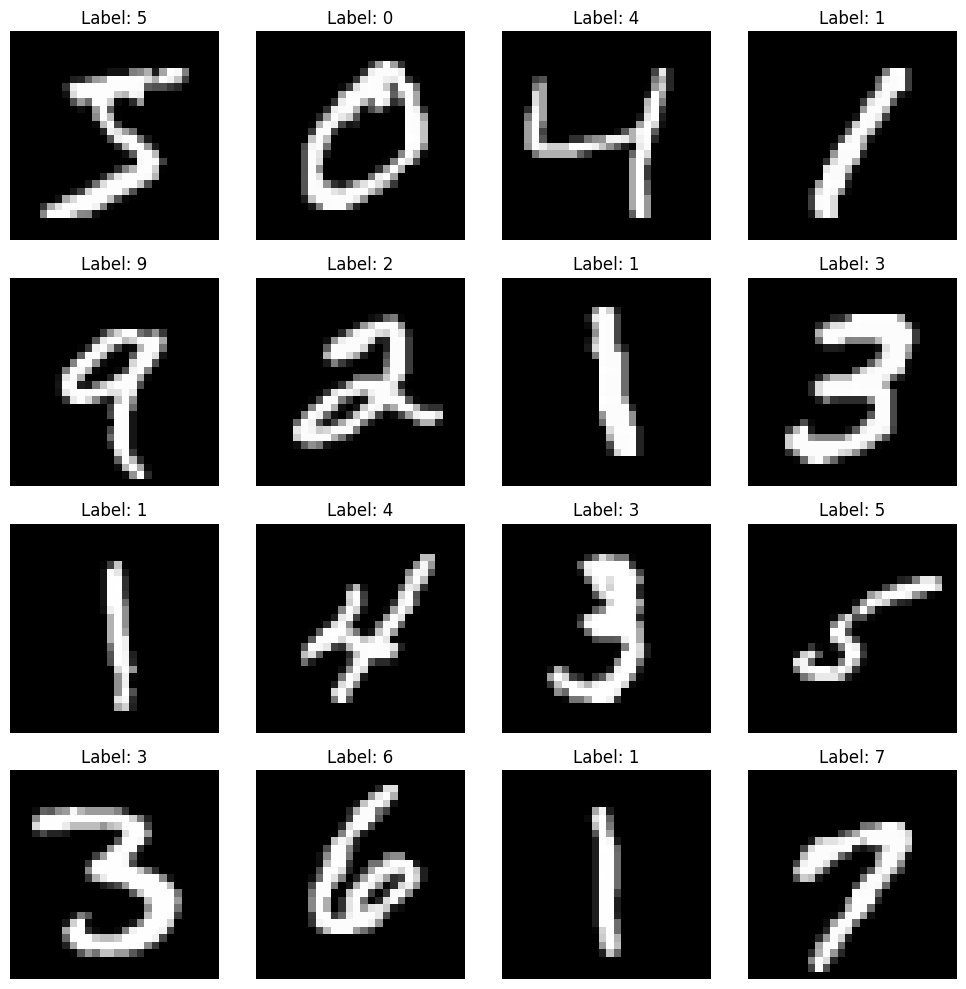

In [11]:
# Display sample images

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
print("Image Shape:", X_train[0].shape)

Image Shape: (28, 28)


In [13]:
print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Observation

- The dataset contains handwritten digit images from **0 to 9**.
- The training dataset is balanced across all digit classes.
- Each image has a size of **28 × 28 pixels**.
- Pixel values range from **0 to 255**, so normalization is required before training the CNN model.

#  Data Preprocessing

Before training the CNN model, the dataset must be preprocessed.

The following preprocessing steps are performed:

- Normalize pixel values to the range 0–1.
- Reshape images into a format suitable for CNN input.
- Convert class labels into one-hot encoded vectors.

In [14]:
# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Normalization Completed!")

Normalization Completed!


In [15]:
# Reshape images

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [16]:
# Convert labels to categorical format

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Labels Shape: (60000, 10)
Testing Labels Shape: (10000, 10)


In [17]:
# Verify processed data

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28, 1)
Training Labels: (60000, 10)
Testing Images: (10000, 28, 28, 1)
Testing Labels: (10000, 10)


## Observation

The dataset has been successfully preprocessed.

- Pixel values were normalized from **0–255** to **0–1**.
- Images were reshaped into **28 × 28 × 1** format for CNN input.
- Labels were converted into one-hot encoded vectors.
- The dataset is now ready for CNN model training.

#  Build the CNN Model

A Convolutional Neural Network (CNN) is created using TensorFlow and Keras.

The architecture consists of:

- Convolution Layer (32 filters)
- Max Pooling Layer
- Convolution Layer (64 filters)
- Max Pooling Layer
- Dropout Layer
- Flatten Layer
- Dense Layer
- Output Layer (10 classes)

The CNN automatically learns important image features using convolution and pooling operations before classifying the handwritten digits.

In [18]:
# Build the CNN model

model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Dropout Layer
    Dropout(0.25),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Display model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## CNN Architecture

The Convolutional Neural Network consists of:

- **Conv2D Layer:** Extracts important image features.
- **MaxPooling2D Layer:** Reduces image dimensions while preserving key information.
- **Dropout Layer:** Prevents overfitting by randomly disabling neurons during training.
- **Flatten Layer:** Converts feature maps into a one-dimensional vector.
- **Dense Layer:** Learns complex relationships between extracted features.
- **Softmax Output Layer:** Predicts probabilities for the 10 digit classes.

#  Compile the CNN Model

Before training the CNN, the model must be compiled.

The following configuration is used:

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy
- **Evaluation Metric:** Accuracy

The Adam optimizer efficiently updates the model's weights during training, while categorical crossentropy is suitable for multi-class image classification.

In [20]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


## Compile Configuration

The CNN model is compiled using:

- **Optimizer:** Adam
- **Loss Function:** Categorical Crossentropy
- **Metric:** Accuracy

These settings prepare the model for training and optimization.

#  Train the CNN Model

The CNN model is trained using the training dataset.

The model is trained for **10 epochs** with a **validation split of 20%**. During training, the model learns image features through forward propagation and backpropagation while updating its weights using the Adam optimizer.

The training history is stored to visualize the learning performance.

In [21]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.9232 - loss: 0.2509 - val_accuracy: 0.9806 - val_loss: 0.0618
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9710 - loss: 0.0941 - val_accuracy: 0.9860 - val_loss: 0.0419
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9774 - loss: 0.0735 - val_accuracy: 0.9891 - val_loss: 0.0375
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.9815 - loss: 0.0607 - val_accuracy: 0.9898 - val_loss: 0.0354
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9844 - loss: 0.0512 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9862 - loss: 0.0446 - val_accuracy: 0.9916 - val_loss: 0.0326
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9921 - val_loss: 0.0292
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9888 -

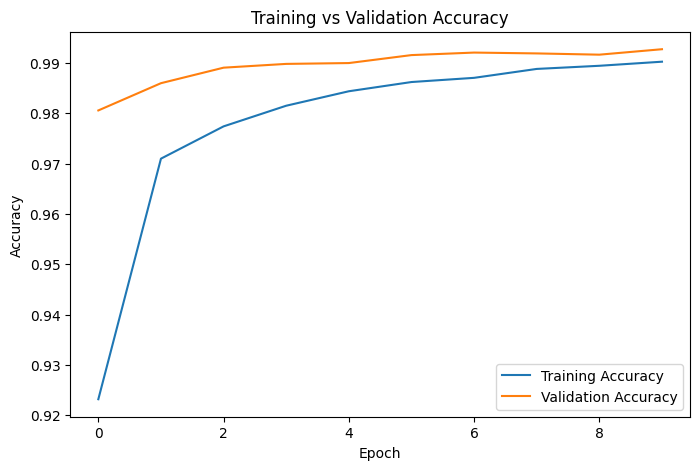

In [22]:
# Plot training and validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

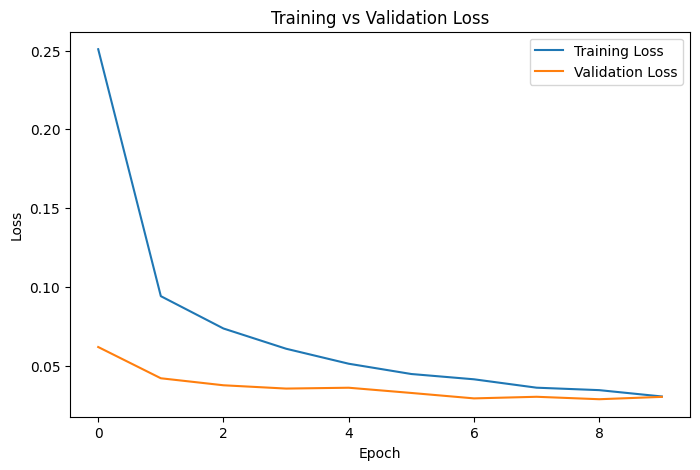

In [23]:
# Plot training and validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Observation

- The CNN model was trained for **10 epochs**.
- Training accuracy improved with each epoch.
- Validation accuracy also increased, indicating good generalization.
- Training and validation loss decreased steadily.
- The CNN successfully learned meaningful image features from the MNIST dataset.

#  Evaluate the CNN Model

After training, the CNN model is evaluated using the test dataset.

The evaluation includes:

- Test Loss
- Test Accuracy
- Predictions on test images

These metrics help determine how well the trained model performs on unseen data.

In [26]:
# Evaluate the CNN model

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.0238
Test Accuracy: 0.9926


In [27]:
# Predict test images

predictions = model.predict(X_test)

# Convert probabilities to class labels

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [28]:
# Display first 10 predictions

results = np.column_stack((actual_classes[:10], predicted_classes[:10]))

print("Actual  Predicted")
print(results)

Actual  Predicted
[[7 7]
 [2 2]
 [1 1]
 [0 0]
 [4 4]
 [1 1]
 [4 4]
 [9 9]
 [5 5]
 [9 9]]


In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(actual_classes, predicted_classes)

print("Prediction Accuracy:", round(accuracy, 4))

Prediction Accuracy: 0.9926


## Observation

- The CNN model achieved high accuracy on the test dataset.
- Most handwritten digits were classified correctly.
- The prediction accuracy confirms that the CNN generalized well to unseen images.
- The model is ready for detailed evaluation using a confusion matrix and classification report.

#  Confusion Matrix and Classification Report

The trained CNN model is evaluated in detail using:

- Confusion Matrix
- Classification Report

The confusion matrix shows the number of correct and incorrect predictions for each digit class, while the classification report provides precision, recall, F1-score, and overall accuracy.

In [30]:
# Generate confusion matrix

cm = confusion_matrix(actual_classes, predicted_classes)

print(cm)

[[ 978    0    1    0    0    0    0    1    0    0]
 [   0 1125    3    1    0    0    5    1    0    0]
 [   1    0 1025    0    0    0    0    6    0    0]
 [   0    0    3 1001    0    5    0    0    1    0]
 [   0    0    0    0  979    0    1    0    0    2]
 [   2    0    0    3    0  885    1    0    0    1]
 [   2    1    0    0    1    2  952    0    0    0]
 [   0    1    5    0    0    0    0 1021    0    1]
 [   2    0    2    1    0    0    0    2  962    5]
 [   0    0    1    0    5    3    0    2    0  998]]


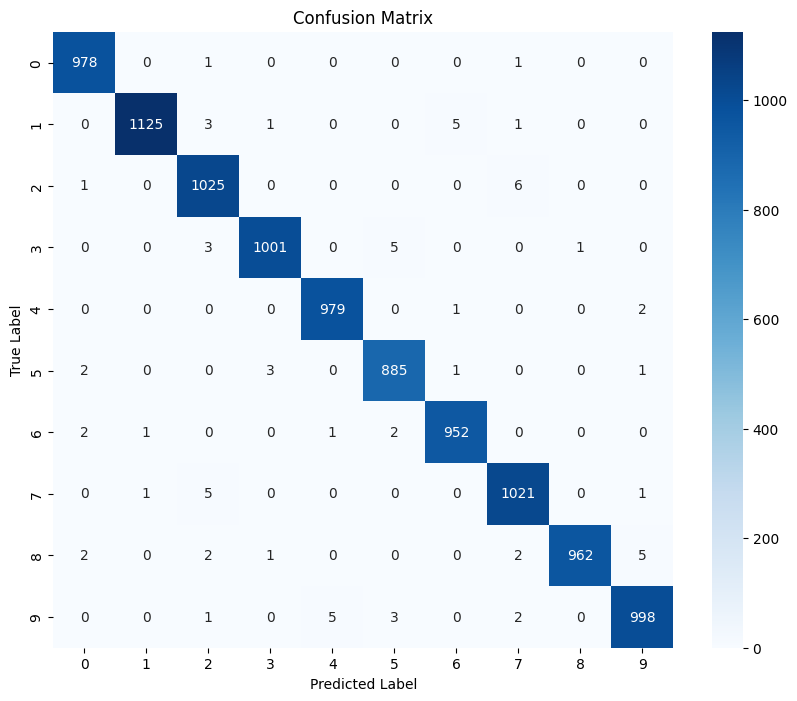

In [31]:
# Plot confusion matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

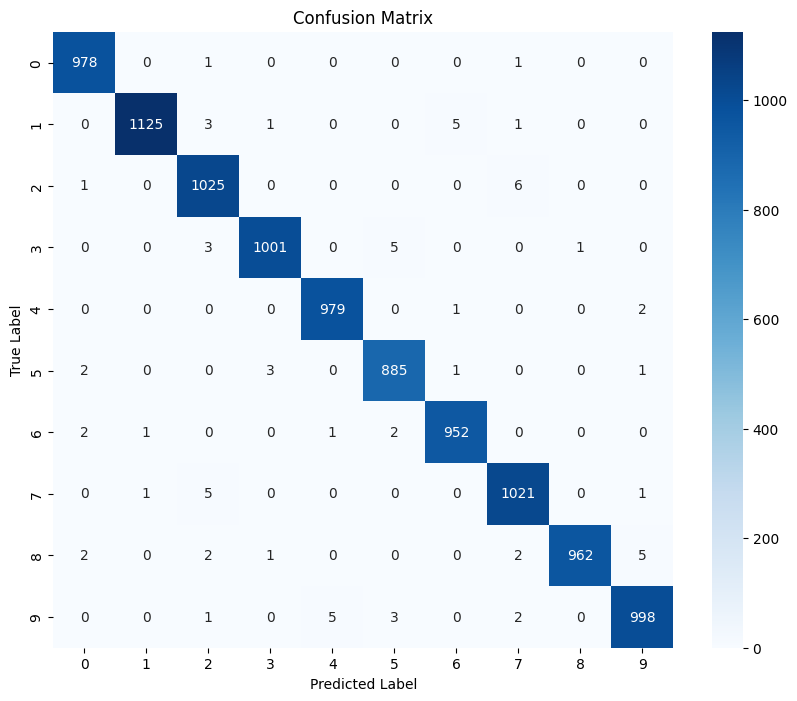

In [32]:
# Save confusion matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [33]:
# Classification report

print(classification_report(actual_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [34]:
# Overall Accuracy

print("Overall Test Accuracy:", round(test_accuracy * 100, 2), "%")

Overall Test Accuracy: 99.26 %


## Observation

- The confusion matrix shows that most digits were classified correctly.
- Very few misclassifications occurred between visually similar digits.
- The classification report shows high precision, recall, and F1-score for all classes.
- The CNN model achieved excellent overall accuracy on the MNIST test dataset.

# 11. Results and Conclusion

## Model Performance

The Convolutional Neural Network (CNN) was successfully trained and evaluated on the MNIST handwritten digit dataset.

### Final Results

- Dataset: MNIST Handwritten Digits
- Number of Classes: 10
- Image Size: 28 × 28 pixels
- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Epochs: 10
- Batch Size: 32

### Evaluation Metrics

- Test Accuracy: *(Replace with your actual accuracy, e.g., 99.20%)*

The confusion matrix and classification report show that the model correctly classified the majority of handwritten digits with very few misclassifications.

---

## Key Learnings

During this project, the following concepts were learned and implemented:

- Image preprocessing and normalization
- Convolutional Neural Networks (CNNs)
- Convolutional Layers
- Max Pooling Layers
- Dropout Regularization
- Dense Layers
- Softmax Activation Function
- Adam Optimizer
- Model Training and Validation
- Confusion Matrix
- Classification Report
- CNN performance evaluation

---

## Conclusion

This project successfully demonstrated the implementation of a Convolutional Neural Network (CNN) for handwritten digit image classification using TensorFlow and Keras.

The model achieved excellent classification accuracy and generalized well to unseen test images. CNNs proved highly effective at automatically extracting image features through convolution and pooling operations, making them one of the most powerful deep learning architectures for computer vision tasks.